In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, hypercube=True, class_sep=0.8, random_state=59)

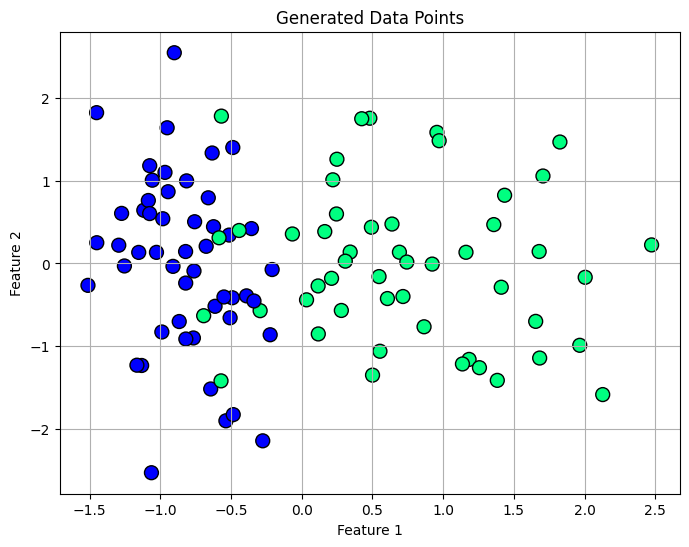

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.title("Generated Data Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# Apply Perceptron Logistic Regression

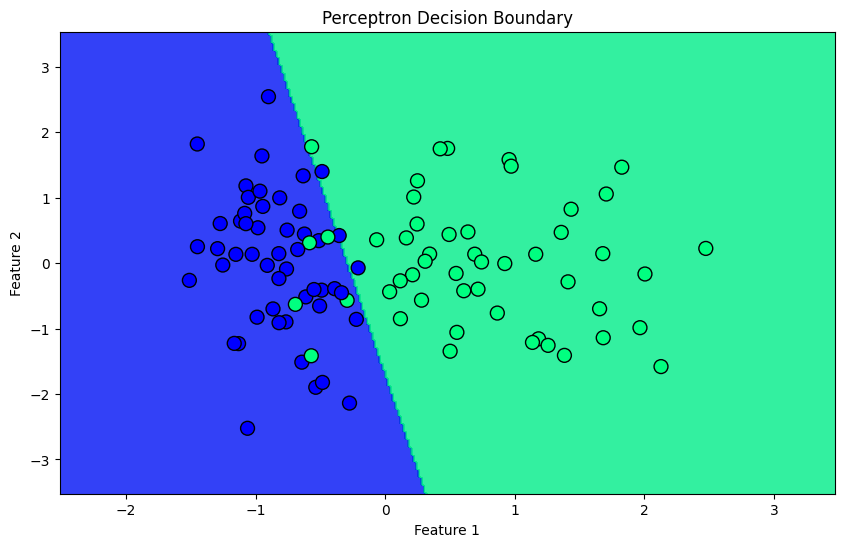

In [43]:
def step(x):
    return 1 if x > 0 else 0

def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

# Apply the perceptron algorithm
b, w = perceptron(X, y)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the decision boundary for the perceptron
# The decision boundary is w[0]*x + w[1]*y + b = 0
# So, y = (-w[0]*x - b) / w[1]
Z_perceptron = np.array([step(np.dot(np.array([1, xi, yi]), np.insert(w, 0, b))) for xi, yi in np.c_[xx.ravel(), yy.ravel()]])
Z_perceptron = Z_perceptron.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_perceptron, alpha=0.8, cmap='winter')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.title("Perceptron Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Visualize Perceptron Trick

In [ ]:
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

def step(x):
    return 1 if x > 0 else 0

def perceptron(X, y):
    m_list = []
    b_list = []

    X_biased = np.insert(X, 0, 1, axis=1) # Add bias term (x0 = 1)
    weights = np.ones(X_biased.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X_biased[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X_biased[j]

        # Store slope (m) and intercept (b) at each step
        # Decision boundary: w0*x0 + w1*x1 + w2*x2 = 0
        # For our 2D case with bias: weights[0]*1 + weights[1]*x1 + weights[2]*x2 = 0
        # x2 = -(weights[1]/weights[2])*x1 - (weights[0]/weights[2])
        # So, m = -(weights[1]/weights[2]) and b = -(weights[0]/weights[2])

        # Handle the case where weights[2] might be zero to avoid division by zero
        if weights[2] != 0:
            m_list.append(-(weights[1] / weights[2]))
            b_list.append(-(weights[0] / weights[2]))
        else:
            # If weights[2] is zero, the line is vertical (or ill-defined for this form)
            # For simplicity in visualization, we'll append the last valid m, b or a default
            if m_list and b_list:
                m_list.append(m_list[-1])
                b_list.append(b_list[-1])
            else:
                m_list.append(0) # Default to a horizontal line if no previous values
                b_list.append(0)

    return m_list, b_list

# Apply the perceptron algorithm to get the history of m and b
m_history, b_history = perceptron(X, y)

# Set up the plot for animation
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
ax.set_title("Perceptron Decision Boundary Animation")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

# Get data limits for the decision boundary line
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Initialize the line for the decision boundary
line, = ax.plot([], [], 'r--', lw=2)

def update(frame):
    if frame < len(m_history):
        m_val = m_history[frame]
        b_val = b_history[frame]

        # Calculate y values for the decision boundary line
        # y = m*x + b
        line_y = m_val * np.array([x_min, x_max]) + b_val
        line.set_data([x_min, x_max], line_y)
        ax.set_title(f"Perceptron Decision Boundary (Iteration {frame})")
    return line,

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(m_history), blit=True, interval=50)

# Close the static plot to only display the animation
plt.close(fig)

# Display the animation (note: in some environments like Colab, it might display as HTML5 video)
from IPython.display import HTML
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

# Sigmoid Function

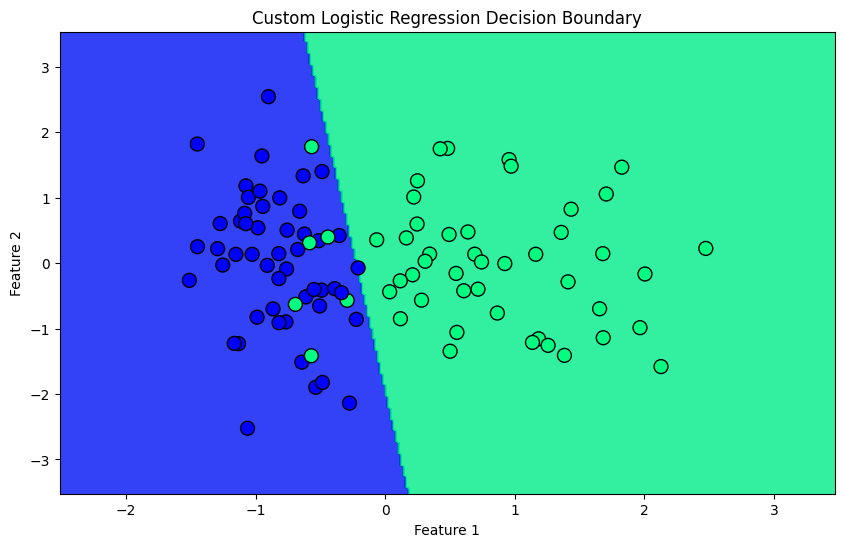

In [44]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logistic_regression(X, y, learning_rate=0.1, n_iterations=1000):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])

    for i in range(n_iterations):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + learning_rate*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

b_lr, w_lr = logistic_regression(X, y)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the decision boundary for logistic regression
# The decision boundary is where sigmoid(w_lr[0]*x + w_lr[1]*y + b_lr) = 0.5
# which means w_lr[0]*x + w_lr[1]*y + b_lr = 0
Z_lr = np.dot(np.c_[xx.ravel(), yy.ravel()], w_lr) + b_lr
Z_lr = sigmoid(Z_lr).reshape(xx.shape)

# Classify based on the sigmoid output (0.5 threshold)
Z_lr_classified = (Z_lr > 0.5).astype(int)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_lr_classified, alpha=0.8, cmap='winter')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.title("Custom Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Apply Logistic Regression

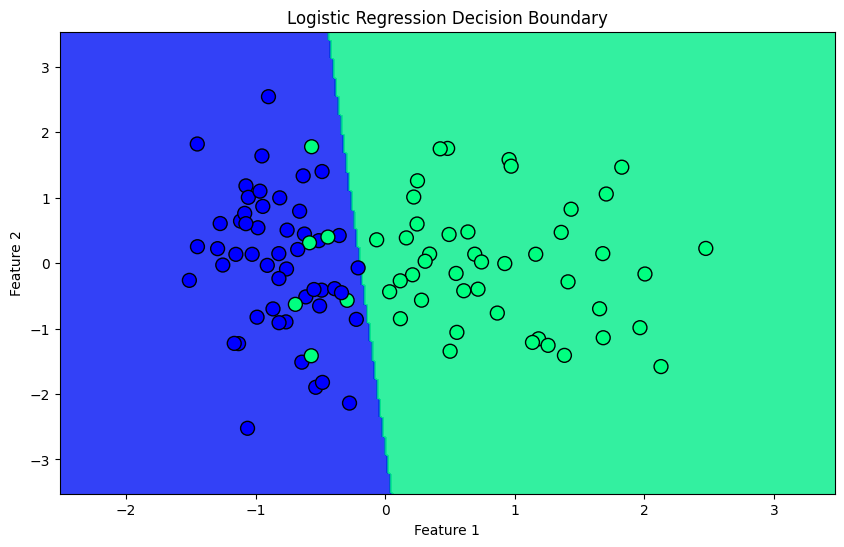

In [45]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X, y)

# Get the coefficients and intercept
coef_ = model.coef_[0]
intercept_ = model.intercept_[0]

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='winter')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

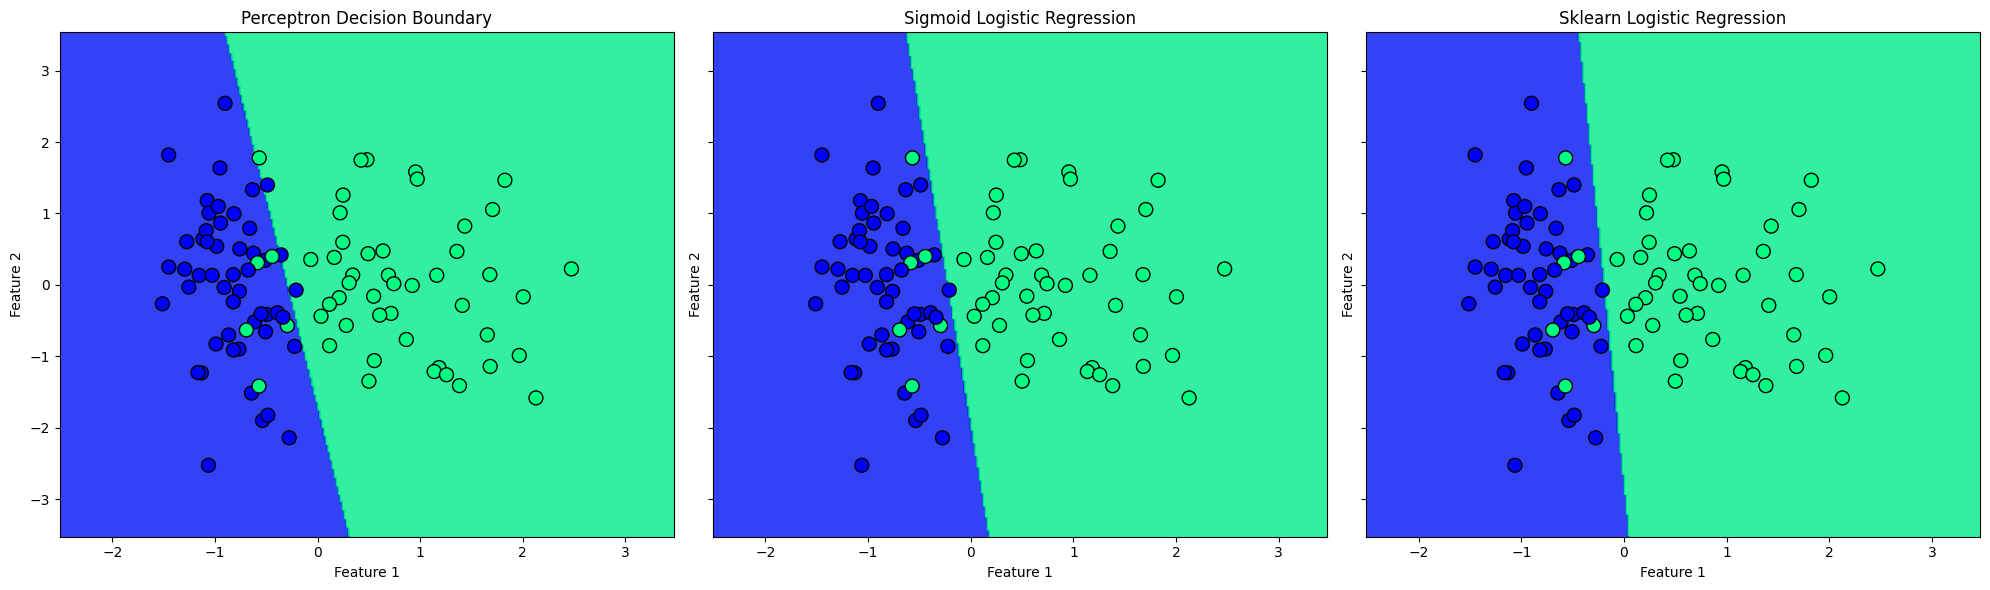

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

# Perceptron Decision Boundary
axes[0].contourf(xx, yy, Z_perceptron, alpha=0.8, cmap='winter')
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
axes[0].set_title("Perceptron Decision Boundary")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Sigmoid Logistic Regression Decision Boundary
axes[1].contourf(xx, yy, Z_lr_classified, alpha=0.8, cmap='winter')
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
axes[1].set_title("Sigmoid Logistic Regression")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

# Scikit-learn Logistic Regression Decision Boundary
axes[2].contourf(xx, yy, Z, alpha=0.8, cmap='winter')
axes[2].scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
axes[2].set_title("Sklearn Logistic Regression")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Gradient Descent Improved Version

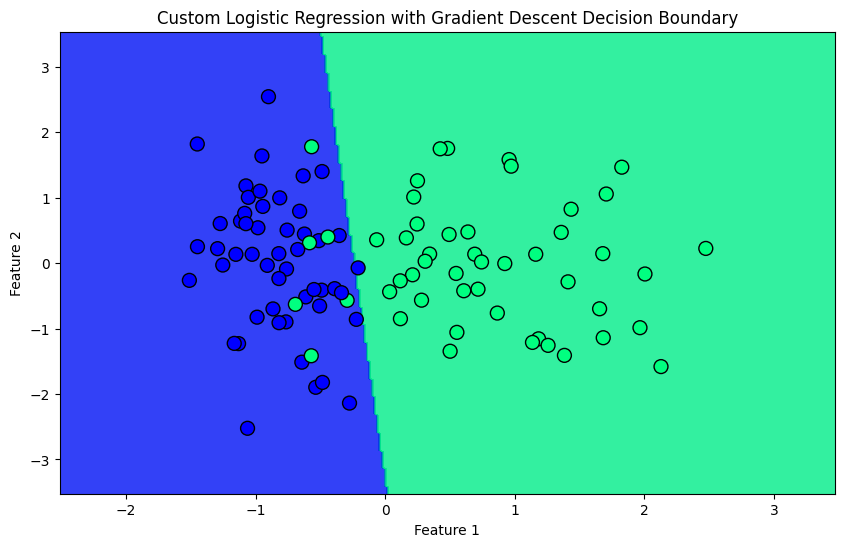

In [50]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logistic_regression_gd(X, y, learning_rate=0.1, n_iterations=1000):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.zeros(X.shape[1])

    for _ in range(n_iterations):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + learning_rate*(np.dot((y-y_hat),X)/X.shape[0])

    return weights[0], weights[1:]

# Apply the custom logistic regression algorithm with Gradient Descent
b_lr_gd, w_lr_gd = logistic_regression_gd(X, y)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Calculate the decision boundary for logistic regression
# The decision boundary is where sigmoid(w_lr[0]*x + w_lr[1]*y + b_lr) = 0.5
# which means w_lr[0]*x + w_lr[1]*y + b_lr = 0
Z_lr_gd = np.dot(np.c_[xx.ravel(), yy.ravel()], w_lr_gd) + b_lr_gd
Z_lr_gd = sigmoid(Z_lr_gd).reshape(xx.shape)

# Classify based on the sigmoid output (0.5 threshold)
Z_lr_gd_classified = (Z_lr_gd > 0.5).astype(int)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_lr_gd_classified, alpha=0.8, cmap='winter')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.title("Custom Logistic Regression with Gradient Descent Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

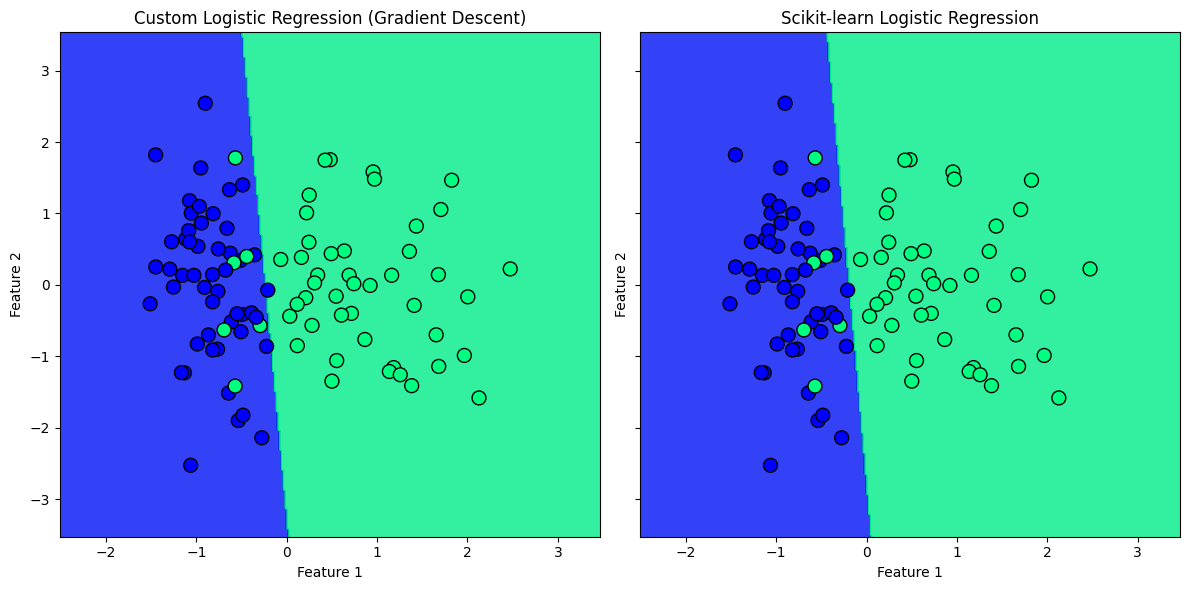

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Custom Logistic Regression with Gradient Descent Decision Boundary
axes[0].contourf(xx, yy, Z_lr_gd_classified, alpha=0.8, cmap='winter')
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
axes[0].set_title("Custom Logistic Regression (Gradient Descent)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Scikit-learn Logistic Regression Decision Boundary
axes[1].contourf(xx, yy, Z, alpha=0.8, cmap='winter')
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
axes[1].set_title("Scikit-learn Logistic Regression")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()